## Bonus task 24: Better DT (<1 week deadline!)
Re-Implement the **ID3 algorithm** in the scikit-learn compatible maner. The most convenient implementation (for my taste) will be used for following classes, so you should be ready for 5-10 minute talk about your implementation.



## Bonus Task 25: Prunning
Select any kind of prunning algorithms except for Cost-Complexity Prunnig (e.g. from [here](http://dspace.mit.edu/bitstream/handle/1721.1/6453/AIM-930.pdf?sequence=2)) and implement it.

Буду реализовывать Pessimistic Pruning из предложенной статьи

In [5]:
from __future__ import annotations
import typing

import numpy
import graphviz
import sklearn.base

class ID3Classifier(sklearn.base.ClassifierMixin):
    def __init__(self, num_classes: typing.Optional[int] = None):
        self.num_classes_ = num_classes

    def fit(self, X: numpy.ndarray, y: numpy.ndarray):
        if len(X) != len(y):
            raise ValueError("X and y must have the same number of rows")
        if len(X) < 1:
            raise ValueError("ID3Classifier requires at least one sample")
        if X.ndim != 2:
            raise ValueError("X must have two dimensions")
        if y.ndim != 1:
            raise ValueError("y must have one dimension")
        if y.dtype != int:
            raise ValueError(f"Targets (y) must be integers, received {y.dtype}")
        
        # Compute and store target distribution at this node
        classes, counts = numpy.unique(y, return_counts=True)
        if self.num_classes_ is None:
            self.num_classes_ = len(classes)
        if (y < 0).any() or (y >= self.num_classes_).any():
            raise ValueError(f"Targets must be integers between 0 and {self.num_classes_ - 1}")
        self.classes_ = numpy.zeros(self.num_classes_)
        self.classes_[classes] = counts

        # Base cases: all samples same class, no features left
        if X.shape[1] == 0 or len(classes) == 1:
            self.is_leaf_, self.num_leafs_ = True, 1
            self.misclassified_ = (y != numpy.argmax(self.classes_)).sum()
            return self
        
        self.is_leaf_, self.num_leafs_, self.misclassified_ = False, 0, 0
        self.children_: typing.Dict[typing.Any, ID3Classifier] = {}
        self.best_feature_ = self._select_best_feature(X, y)
        new_X = numpy.delete(X, self.best_feature_, axis = 1)
        for value in numpy.unique(X[:, self.best_feature_]):
            mask = X[:, self.best_feature_] == value
            self.children_[value] = ID3Classifier(self.num_classes_).fit(new_X[mask], y[mask])
            # Update stats about the node
            self.num_leafs_ += self.children_[value].num_leafs_
            self.misclassified_ += self.children_[value].misclassified_
        return self
    
    def predict_proba(self, X):
        return numpy.vstack([ self._predict_proba_one_object(x) for x in X])
    
    def predict_log_proba(self, X: numpy.ndarray) -> numpy.ndarray:
        return numpy.log(self.predict_proba(X))
        
    def predict(self, X: numpy.ndarray) -> numpy.ndarray:
        return numpy.argmax(self.predict_proba(X), axis = 1)
    
    def score(self, X: numpy.ndarray, y: numpy.ndarray) -> float:
        return (self.predict(X) == y).mean()
        
    def _select_best_feature(self, X: numpy.ndarray, y: numpy.ndarray) -> int:
        """Select the feature with the highest information gain."""
        return numpy.argmax([self._information_gain(X[:, feature], y) for feature in range(X.shape[1])])
    
    def _information_gain(self, feature: numpy.ndarray, y: numpy.ndarray) -> float:
        """Calculate the information gain for a given feature."""
        weighted_entropy = 0.0
        for value, count in zip(*numpy.unique(feature, return_counts=True)):
            weighted_entropy += (count / len(y)) * self._entropy(y[feature == value])
        return self._entropy(y) - weighted_entropy

    def _entropy(self, y: numpy.ndarray) -> float:
        """Calculate the entropy of a target array."""
        _, counts = numpy.unique(y, return_counts=True)
        probabilities = counts / counts.sum()
        return -numpy.sum(probabilities * numpy.log2(probabilities + 1e-10))
    
    def _predict_proba_one_object(self, x: numpy.ndarray) -> numpy.ndarray:
        """Calculate prediction for one sample."""
        if not hasattr(self, "is_leaf_"):
            raise AttributeError("This ID3Classifier instance is not fitted yet. Call 'fit' first.")
        
        if self.is_leaf_:
            return self.classes_ / self.classes_.sum()
        x_new = numpy.delete(x, self.best_feature_, axis = 0)
        return self.children_[x[self.best_feature_]]._predict_proba_one_object(x_new)
    
    def visualize(self, feature_names: typing.List[str], graph: typing.Optional[graphviz.Digraph] = None):
        """Recursively visualize the decision tree using Graphviz."""
        if graph is None:
            graph = graphviz.Digraph(comment='Decision Tree')

        if self.is_leaf_:
            graph.node(str(id(self)), f"{int(self.classes_.sum())} samples, {numpy.argmax(self.classes_)}")
        else:
            graph.node(str(id(self)), f"Feature: {feature_names[self.best_feature_]}")
            for value, child in self.children_.items():
                feature_names_cpy = feature_names.copy()
                feature_names_cpy.pop(self.best_feature_)
                child.visualize(feature_names_cpy, graph)
                graph.edge(str(id(self)), str(id(child)), label=f"{value}")
        return graph
    
    def pessimistic_pruning(self):
        """Pessimistic pruning following 2.3 from https://dspace.mit.edu/bitstream/handle/1721.1/6453/AIM-930.pdf?sequence=2"""
        if not hasattr(self, "is_leaf_"):
            raise AttributeError("Pruning requires a fitted ID3Classifier. Call 'fit' first.")
        if self.is_leaf_:
            return
        
        num_samples = self.classes_.sum()
        expected_num_errors = self.misclassified_ + self.num_leafs_ / 2
        std = numpy.sqrt((expected_num_errors * (num_samples - expected_num_errors)) / num_samples)

        best_leaf_errors = self.classes_.sum() - self.classes_.max()
        if best_leaf_errors < std:
            # Prune this node
            self.is_leaf_, self.num_leafs_ = True, 1
            self.misclassified_ = best_leaf_errors
        else:
            for value, child in self.children_.items():
                child.pessimistic_pruning()
                self.num_leafs_ += self.children_[value].num_leafs_
                self.misclassified_ += self.children_[value].misclassified_

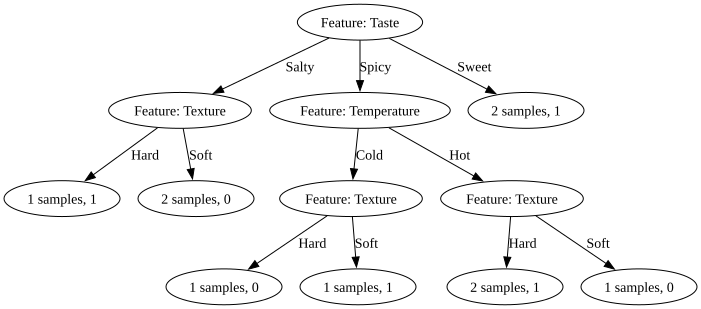

array([1, 0], dtype=int64)

In [6]:
# Используем датасет из семинара
import pandas

train_dataset = {
    'Taste': ['Salty','Spicy','Spicy','Spicy','Spicy','Sweet','Salty','Sweet','Spicy','Salty'],
    'Temperature': ['Hot','Hot','Hot','Cold','Hot','Cold','Cold','Hot','Cold','Hot'],
    'Texture': ['Soft','Soft','Hard','Hard','Hard','Soft','Soft','Soft','Soft','Hard'],
    'Eat': ['No','No','Yes','No','Yes','Yes','No','Yes','Yes','Yes']
}
train_dataframe = pandas.DataFrame(train_dataset, columns=['Taste','Temperature','Texture','Eat'])
feature_names = train_dataframe.columns[:-1].tolist()
train_X = train_dataframe[feature_names].to_numpy()
train_y = (train_dataframe['Eat'] == 'Yes').astype(int).to_numpy()

test_dataset = {
    'Taste': ['Salty', 'Spicy'],
    'Temperature': ['Hot', 'Hot'],
    'Texture': ['Hard', 'Soft'],
}
test_dataframe = pandas.DataFrame(test_dataset, columns=['Taste','Temperature','Texture','Eat'])
feature_names = test_dataframe.columns[:-1].tolist()
test_X = test_dataframe[feature_names].to_numpy()

clf = ID3Classifier().fit(train_X, train_y)
display(clf.visualize(feature_names=feature_names))
clf.predict(test_X)

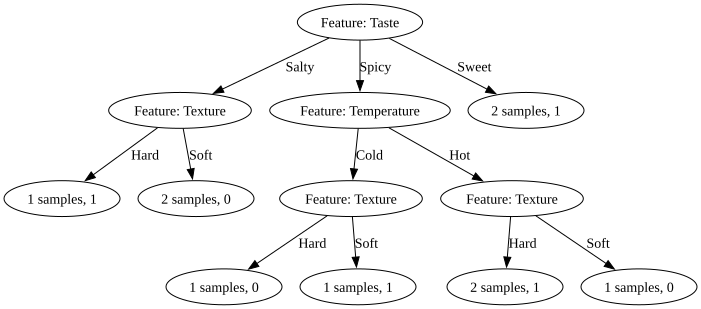

In [7]:
clf.pessimistic_pruning()
display(clf.visualize(feature_names=feature_names))
# Pruning ничего не сделал :(

In [8]:
# Чтобы проверить работу pruning, восстановим датасет из дерева, представленного в статье
# https://dspace.mit.edu/bitstream/handle/1721.1/6453/AIM-930.pdf?sequence=2

FEATURE_VALUES = {
    'TSH': [ 5, 7 ],
    'T4U measured': [ 't', 'f' ],
    'age': [ 43, 44 ],
    'query hypothyroid': [ 't', 'f' ],
    'FTI': [ 64, 65 ],
    'thyroid surgery': [ 't', 'f' ],
    'T3': [ 2, 3 ],
    'sex': [ 'M', 'F' ],
    'referral source': [ 'SVI', '<other>' ],
    'on thyroxine': [ 't', 'f' ],
    'TT4': [ 150, 151 ],
    'target': [ 0, 1, 2, 3 ] # [ 'negative', 'secondary hypothyroid', 'primary hypothyroid', 'compensated hypothyroid' ]
}

def generate_sample(features):
    sample = {}
    for key, values in FEATURE_VALUES.items():
        if key in features:
            sample[key] = features[key]
        else:
            sample[key] = numpy.random.choice(values)
    return sample

numpy.random.seed(42)
dataset = []
for _ in range(1918):
    dataset.append(generate_sample({ 'TSH': 5, 'T4U measured': 't', 'target': 0}))
for _ in range(58):
    dataset.append(generate_sample({ 'TSH': 5, 'T4U measured': 'f', 'age': 44, 'target': 0}))
for _ in range(41):
    dataset.append(generate_sample({ 'TSH': 5, 'T4U measured': 'f', 'age': 43, 'query hypothyroid': 'f', 'target': 0}))
for _ in range(1):
    dataset.append(generate_sample({ 'TSH': 5, 'T4U measured': 'f', 'age': 43, 'query hypothyroid': 't', 'target': 1}))
for _ in range(51):
    dataset.append(generate_sample({ 'TSH': 7, 'FTI': 64, 'thyroid surgery': 'f', 'T3': 2, 'target': 2}))
for _ in range(1):
    dataset.append(generate_sample({ 'TSH': 7, 'FTI': 64, 'thyroid surgery': 'f', 'T3': 3, 'sex': 'M', 'target': 0}))
for _ in range(4):
    dataset.append(generate_sample({ 'TSH': 7, 'FTI': 64, 'thyroid surgery': 'f', 'T3': 3, 'sex': 'F', 'target': 2}))
for _ in range(1):
    dataset.append(generate_sample({ 'TSH': 7, 'FTI': 64, 'thyroid surgery': 't', 'referral source': 'SVI', 'target': 2}))
for _ in range(2):
    dataset.append(generate_sample({ 'TSH': 7, 'FTI': 64, 'thyroid surgery': 't', 'referral source': '<other>', 'target': 0}))
for _ in range(32):
    dataset.append(generate_sample({ 'TSH': 7, 'FTI': 65, 'on thyroxine': 't', 'target': 0}))
for _ in range(3):
    dataset.append(generate_sample({ 'TSH': 7, 'FTI': 65, 'on thyroxine': 'f', 'thyroid surgery': 't', 'target': 0}))
for _ in range(120):
    dataset.append(generate_sample({ 'TSH': 7, 'FTI': 65, 'on thyroxine': 'f', 'thyroid surgery': 'f', 'TT4': 150, 'target': 3}))
for _ in range(6):
    dataset.append(generate_sample({ 'TSH': 7, 'FTI': 65, 'on thyroxine': 'f', 'thyroid surgery': 'f', 'TT4': 151, 'target': 0}))
dataset = pandas.DataFrame(dataset)
dataset

,TSH,T4U measured,age,query hypothyroid,FTI,thyroid surgery,T3,sex,referral source,on thyroxine,TT4,target
0,5,t,43,f,64,t,2,F,SVI,t,150,0
1,5,t,44,t,64,t,2,F,SVI,f,151,0
2,5,t,44,t,65,t,3,F,<other>,f,151,0
3,5,t,44,f,65,t,2,F,<other>,f,150,0
4,5,t,44,t,64,t,2,M,<other>,f,151,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2233,7,f,43,t,65,f,3,M,<other>,f,151,0
2234,7,t,43,f,65,f,3,M,SVI,f,151,0
2235,7,f,44,f,65,f,2,F,<other>,f,151,0
2236,7,t,44,f,65,f,3,F,SVI,f,151,0


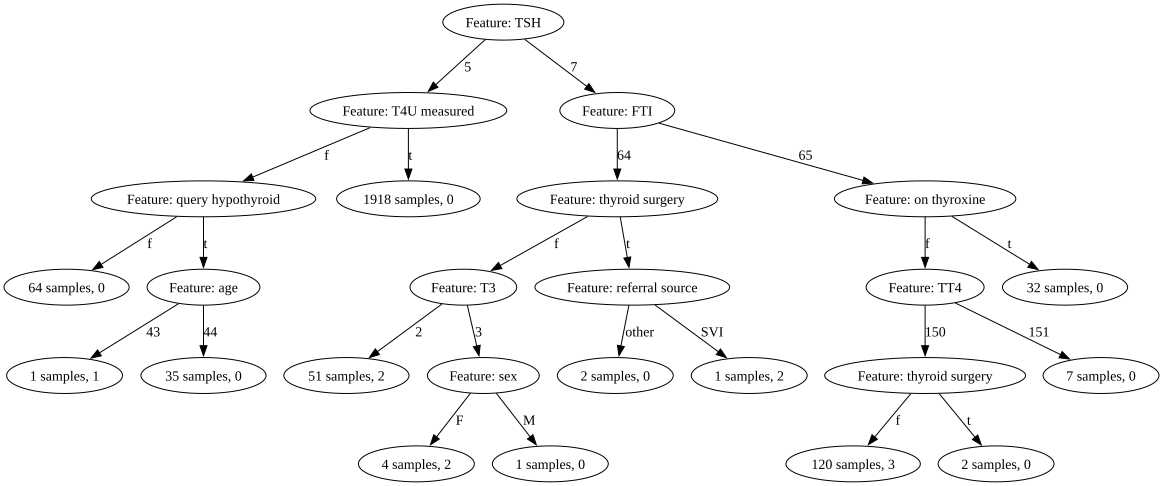

In [9]:
feature_names = dataset.columns[:-1].tolist()
train_X = dataset[feature_names].to_numpy()
train_y = dataset['target'].astype(int).to_numpy()

clf = ID3Classifier().fit(train_X, train_y)
display(clf.visualize(feature_names=feature_names))
# Получилось, конечно, не точь-в-точь такое же дерево, как в статье. Но это и ожидаемо: данные у нас другие.
# Общие закономерности сохранены, разбиения в целом происходят по тем же признакам.

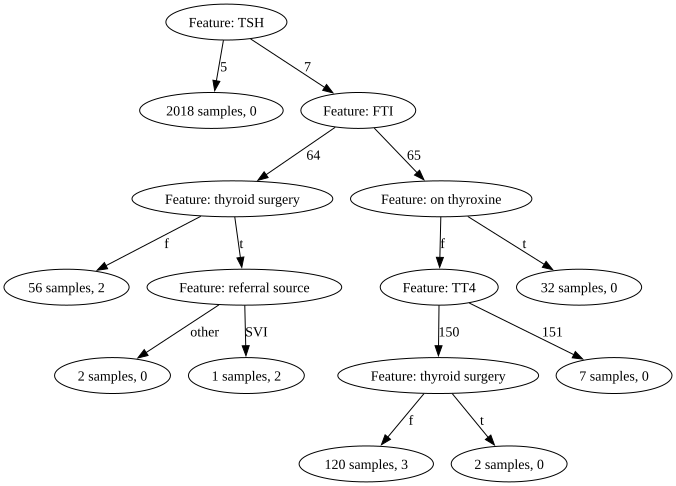

In [10]:
clf.pessimistic_pruning()
display(clf.visualize(feature_names=feature_names))
# Легко заметить, что pruning сработал так, как описано в статье.

## Bonus Task 26: Extra trees
Random forest isn't the only option to combine decision trees into ensembles. Your goal is to write a code for [`ExtraTrees`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.ExtraTreesClassifier.html). In addition to that, explain the difference with RF and provide some insights on practical tips, like 
* should I use more trees?
* should I use deeper trees?
* etc.

В отличие от RF, ExtraTrees обучает каждое дерево на полных данных без бутстрапирования, но разделение объектов в вершинах деревьев происходит не путем оптимизации какого-либо критерия, а случайным образом. В каждой вершине случайным образом выбирается некоторое количество вариантов разделения объектов (признак и порог), и лучший из них используется в качестве итогового разделяющего правила в этой вершине. Такой подход добавляет случайности в получающиеся деревья, что обычно снижает variance за счёт увеличения bias.

In [11]:
import sklearn.tree

class ExtraTreesClassifier:
    def __init__(self, n_estimators = 100, max_features = 'sqrt', max_depth = None):
        self.n_estimators = n_estimators
        self.max_features = max_features
        self.max_depth = max_depth
        self.trees = []
    
    def fit(self, X, y):
        self.trees = []
        for _ in range(self.n_estimators):
            tree = sklearn.tree.DecisionTreeClassifier(
                max_features = self.max_features,
                max_depth = self.max_depth,
                splitter = 'random'
            )
            self.trees.append(tree.fit(X, y))
    
    def predict(self, X):
        tree_preds = numpy.array([tree.predict(X) for tree in self.trees])
        return numpy.apply_along_axis(lambda x: numpy.argmax(numpy.bincount(x)), axis=0, arr=tree_preds)

In [12]:
import sklearn.datasets
from sklearn.model_selection import train_test_split

X, y = sklearn.datasets.load_digits(return_X_y = True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

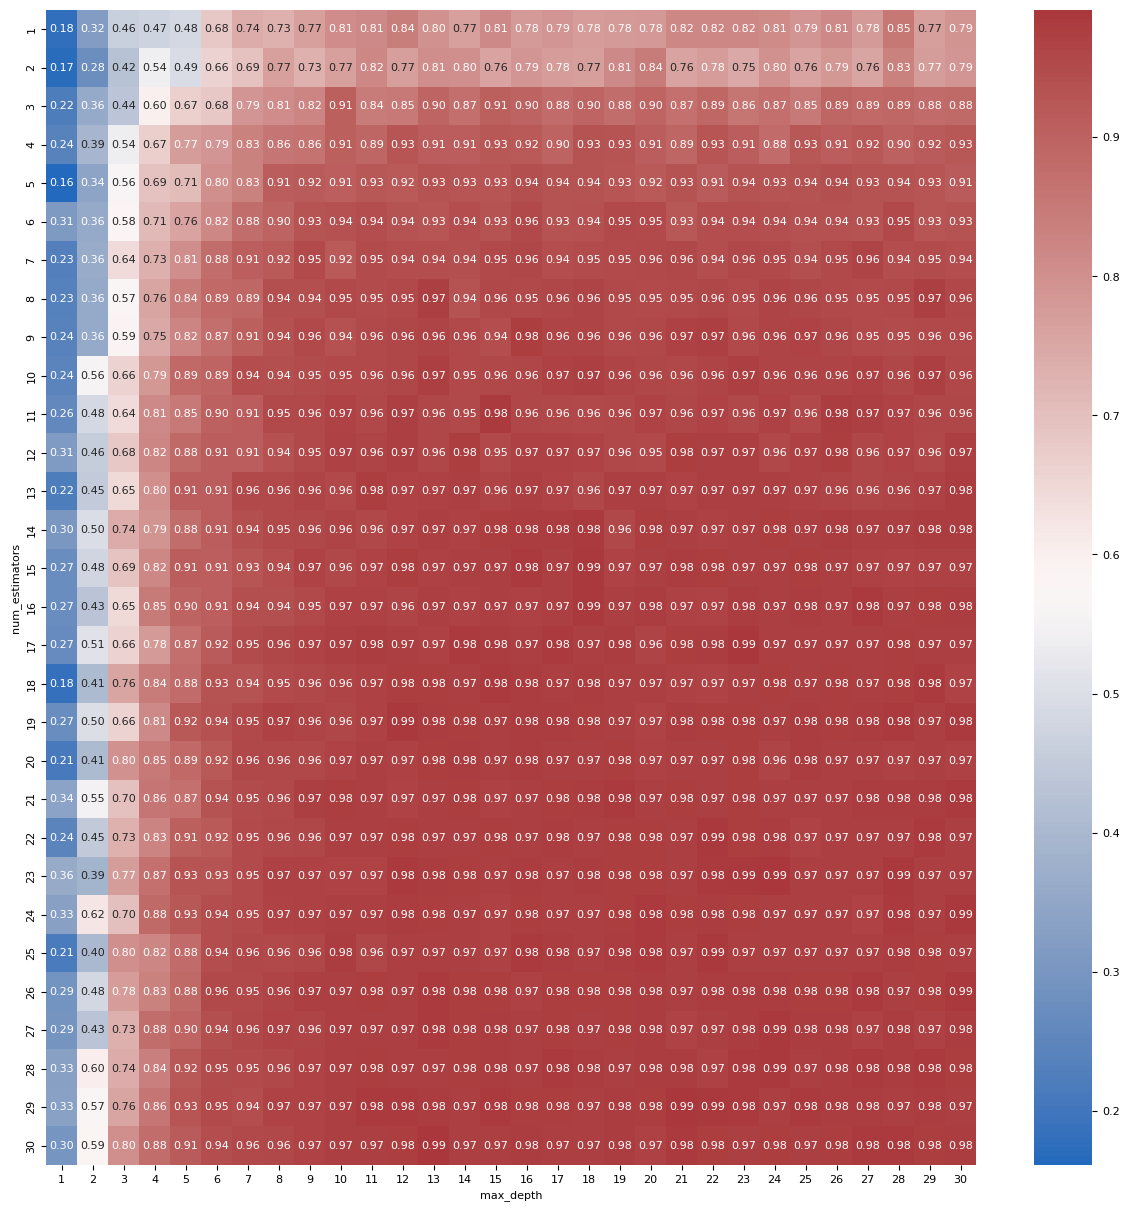

In [13]:
import seaborn
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

MAX_ESTIMATORS = 30
MAX_DEPTH = 30

results = numpy.zeros((MAX_DEPTH, MAX_ESTIMATORS))
for n_estimators in range(1, MAX_ESTIMATORS + 1):
    for max_depth in range(1, MAX_DEPTH + 1):
        clf = ExtraTreesClassifier(n_estimators = n_estimators, max_features = 'sqrt', max_depth = max_depth)
        clf.fit(X_train, y_train)
        results[n_estimators - 1][max_depth - 1] = accuracy_score(y_test, clf.predict(X_test))


plt.figure(figsize = (15, 15))
plt.rcParams.update({'font.size': 8})
seaborn.heatmap(results, cmap = "vlag", annot = True, fmt = "0.2f", xticklabels = range(1, MAX_DEPTH + 1), yticklabels = range(1, MAX_ESTIMATORS + 1))
plt.xlabel("max_depth")
plt.ylabel("num_estimators")
None

Лучшее качество достигается при использовании оптимального количества деревьев соответствующей глубины.

При использовании небольшого количества глубоких деревьев, модель сравнима с обычным решающим деревом, и не может достичь хорошего качества. Более того, у глубоких деревьев проявляется переобучение: увеличение глубины ведет к снижению качества предсказаний, что особенно видно в случаях 1 и 2 деревьев. Наблюдается высокий variance при низком bias.

При использовании большого количество неглубоких деревьев, качество также не достигает хороших значений. Тем не менее явного переобучения не наблюдается, то есть рост количества деревьев уменьшает variance. В целом, с увеличением количества деревьев, качество модели просто выходит на плато. Единственным препятствием к безграничному увеличению количества деревьев является производительность, время работы модели.

Таким образом, при решении реальных задач, следует использовать разумное количество деревьев умеренной глубины. Большое количество деревьев приведет к излишнему расходу вычислительных ресурсов, а чрезмерная глубина вызывает переобучение.